In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix


In [2]:
iris = load_iris()


In [3]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)


df['target'] = iris.target

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [4]:
df = df[['petal length (cm)', 'petal width (cm)', 'target']]

print("\nDataset After Selecting Features:\n")
print(df.head())


Dataset After Selecting Features:

   petal length (cm)  petal width (cm)  target
0                1.4               0.2       0
1                1.4               0.2       0
2                1.3               0.2       0
3                1.5               0.2       0
4                1.4               0.2       0


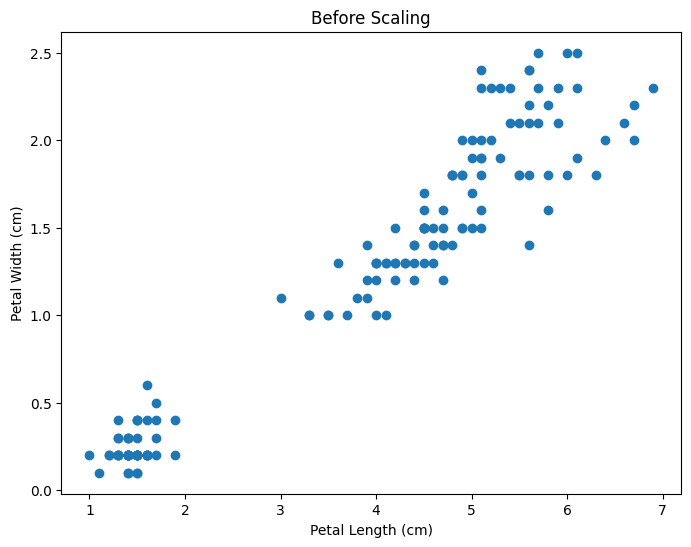

In [5]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['petal length (cm)'],
    df['petal width (cm)']
)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Before Scaling')

plt.show()

In [6]:
scaler = MinMaxScaler()

df['petal length (cm)'] = scaler.fit_transform(
    df[['petal length (cm)']]
)

df['petal width (cm)'] = scaler.fit_transform(
    df[['petal width (cm)']]
)

print("\nAfter Scaling:\n")
print(df.head())



After Scaling:

   petal length (cm)  petal width (cm)  target
0           0.067797          0.041667       0
1           0.067797          0.041667       0
2           0.050847          0.041667       0
3           0.084746          0.041667       0
4           0.067797          0.041667       0


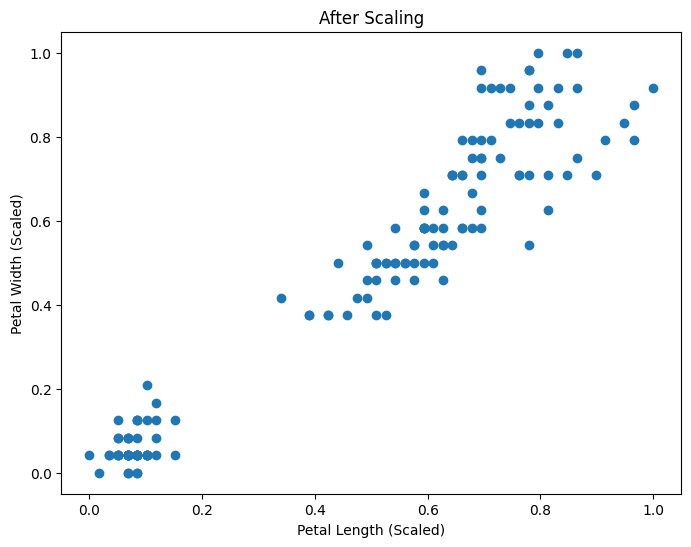

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['petal length (cm)'],
    df['petal width (cm)']
)

plt.xlabel('Petal Length (Scaled)')
plt.ylabel('Petal Width (Scaled)')
plt.title('After Scaling')

plt.show()

In [8]:
km = KMeans(
    n_clusters=3,
    random_state=42
)

y_predicted = km.fit_predict(
    df[['petal length (cm)', 'petal width (cm)']]
)

In [9]:

df['cluster'] = y_predicted

print("\nClustered Data:\n")
print(df.head())


Clustered Data:

   petal length (cm)  petal width (cm)  target  cluster
0           0.067797          0.041667       0        1
1           0.067797          0.041667       0        1
2           0.050847          0.041667       0        1
3           0.084746          0.041667       0        1
4           0.067797          0.041667       0        1


In [10]:

print("\nCluster Centers:\n")
print(km.cluster_centers_)


Cluster Centers:

[[0.7740113  0.81510417]
 [0.07830508 0.06083333]
 [0.55867014 0.51041667]]


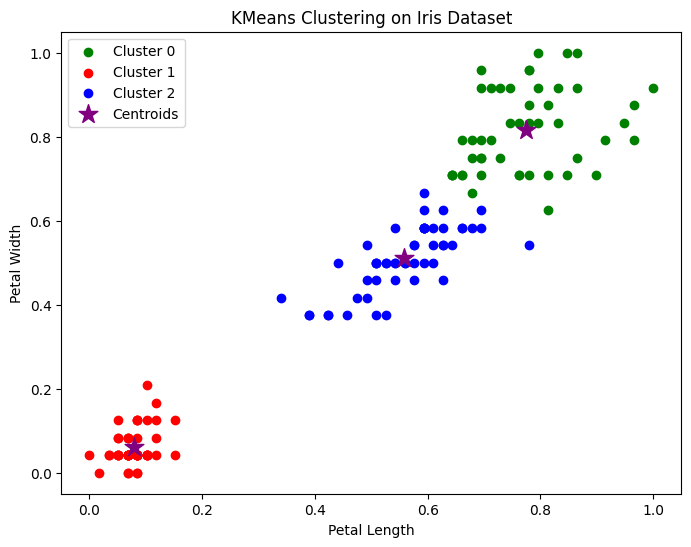

In [11]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.figure(figsize=(8,6))

plt.scatter(
    df1['petal length (cm)'],
    df1['petal width (cm)'],
    color='green',
    label='Cluster 0'
)

plt.scatter(
    df2['petal length (cm)'],
    df2['petal width (cm)'],
    color='red',
    label='Cluster 1'
)

plt.scatter(
    df3['petal length (cm)'],
    df3['petal width (cm)'],
    color='blue',
    label='Cluster 2'
)

# Centroids
plt.scatter(
    km.cluster_centers_[:,0],
    km.cluster_centers_[:,1],
    color='purple',
    marker='*',
    s=200,
    label='Centroids'
)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('KMeans Clustering on Iris Dataset')

plt.legend()

plt.show()

In [12]:
for k in range(3):
    print(f"Cluster {k}:\n")
    print(df[df.cluster == k]['target'].value_counts())
    print("\n")
    

Cluster 0:

target
2    46
1     2
Name: count, dtype: int64


Cluster 1:

target
0    50
Name: count, dtype: int64


Cluster 2:

target
1    48
2     4
Name: count, dtype: int64




In [ ]:
for i in range(3):
    KMeans = KMeans(n_clusters=k , init='l-means++', random_state=42)
    y_means = KMeans.fit_predict(X)

    plt.scatter(X[:,0], X[:,1], c=y_means, cmap='viridis')
    plt.scatter(KMeans.cluster_centers_[:,0], KMeans.cluster_centers_[:,1], c='red', marker='X')
    plt.title(f'KMeans Clustering with k={k}')
    plt.show()


TypeError: 'KMeans' object is not callable

In [13]:

sse = []

k_rng = range(1,11)

for k in k_rng:
    
    km_test = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    km_test.fit(
        df[['petal length (cm)', 'petal width (cm)']]
    )
    
    sse.append(km_test.inertia_)

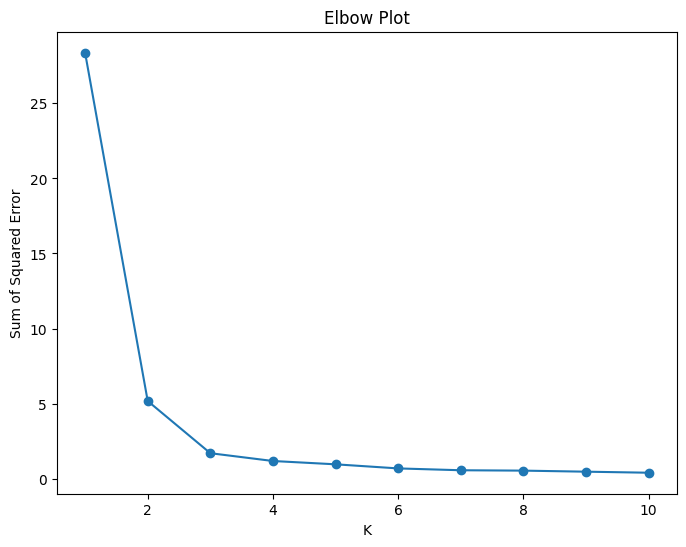

In [14]:
plt.figure(figsize=(8,6))

plt.plot(k_rng, sse, marker='o')

plt.xlabel('K')
plt.ylabel('Sum of Squared Error')
plt.title('Elbow Plot')

plt.show()

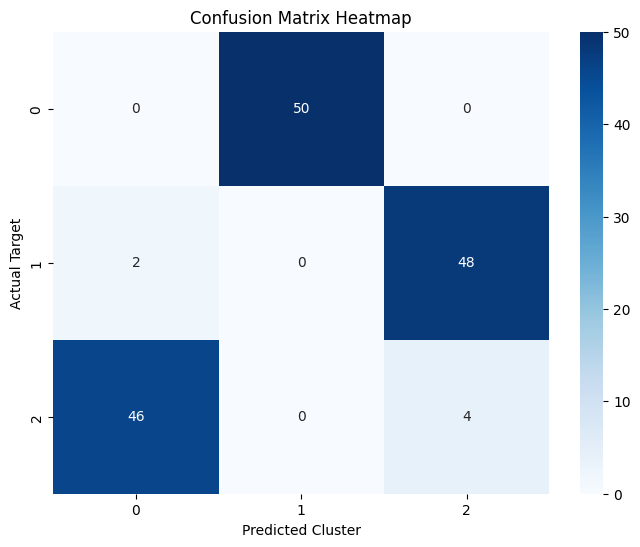

In [15]:
cm = confusion_matrix(df['target'], df['cluster'])

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Target')
plt.title('Confusion Matrix Heatmap')

plt.show()

In [16]:

joblib.dump(km, 'kmeans_iris_model.pkl')

print("\nModel saved successfully as kmeans_iris_model.pkl")



Model saved successfully as kmeans_iris_model.pkl


In [17]:
loaded_model = joblib.load('kmeans_iris_model.pkl')


In [18]:

sample = [[0.5, 0.3]]

prediction = loaded_model.predict(sample)

print("\nSample Cluster Prediction:", prediction[0])


Sample Cluster Prediction: 2


/home/rithik-ca/Documents/Learning and Projects/MLops_Learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
